<a href="https://colab.research.google.com/github/JustusAkuku/Codveda-Technologies-Internship/blob/main/Time_Series_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import drive
drive.mount('/content/drive')
df = pd.read_csv('/content/drive/My Drive/Sentiment dataset.csv')
print("Dataset loaded successfully")
print("Shape:", df.shape)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset loaded successfully
Shape: (732, 15)


In [ ]:
df.head()

,Unnamed: 0.1,Unnamed: 0,Text,Sentiment,Timestamp,User,Platform,Hashtags,Retweets,Likes,Country,Year,Month,Day,Hour
0,0,0,Enjoying a beautiful day at the park! ...,Positive,2023-01-15 12:30:00,User123,Twitter,#Nature #Park,15.0,30.0,USA,2023,1,15,12
1,1,1,Traffic was terrible this morning. ...,Negative,2023-01-15 08:45:00,CommuterX,Twitter,#Traffic #Morning,5.0,10.0,Canada,2023,1,15,8
2,2,2,Just finished an amazing workout! 💪 ...,Positive,2023-01-15 15:45:00,FitnessFan,Instagram,#Fitness #Workout,20.0,40.0,USA,2023,1,15,15
3,3,3,Excited about the upcoming weekend getaway! ...,Positive,2023-01-15 18:20:00,AdventureX,Facebook,#Travel #Adventure,8.0,15.0,UK,2023,1,15,18
4,4,4,Trying out a new recipe for dinner tonight. ...,Neutral,2023-01-15 19:55:00,ChefCook,Instagram,#Cooking #Food,12.0,25.0,Australia,2023,1,15,19


    Check for missing values and duplicates

In [ ]:
print('Missing values in each column:')
display(df.isnull().sum())

print('\nNumber of duplicate rows:')
display(df.duplicated().sum())

Missing values in each column:


,0
Unnamed: 0.1,0
Unnamed: 0,0
Text,0
Sentiment,0
Timestamp,0
User,0
Platform,0
Hashtags,0
Retweets,0
Likes,0



Number of duplicate rows:


np.int64(0)

Plot and decompose the time-series into trend, seasonality and residual components.

In [ ]:
import pandas as pd

# Check if 'Timestamp' is a column, if so, convert to datetime and set as index.
# If it's already the index, this block will be skipped.
if 'Timestamp' in df.columns:
    df['Timestamp'] = pd.to_datetime(df['Timestamp'])
    df = df.set_index('Timestamp')
    print("Timestamp column converted and set as index.")
elif isinstance(df.index, pd.DatetimeIndex) and df.index.name == 'Timestamp':
    print("Timestamp is already the DataFrame's DatetimeIndex. Skipping conversion.")
else:
    print("Warning: 'Timestamp' column not found, and DataFrame index is not named 'Timestamp'. "
          "Please ensure 'Timestamp' column exists or is already the index for time series analysis.")

# CRITICAL FIX: Clean the 'Sentiment' column values by stripping whitespace *before* grouping
# This ensures clean column names in the resulting daily_sentiment_counts DataFrame
if 'Sentiment' in df.columns:
    df['Sentiment'] = df['Sentiment'].str.strip()
else:
    print("Warning: 'Sentiment' column not found in df. Cannot clean sentiment values.")

# Resample the data to daily frequency and count sentiments
if isinstance(df.index, pd.DatetimeIndex) and 'Sentiment' in df.columns: # Ensure index is Datetime and Sentiment exists
    daily_sentiment_counts = df.groupby([pd.Grouper(freq='D'), 'Sentiment']).size().unstack(fill_value=0)

    # Further clean column names by stripping whitespace (redundant if df['Sentiment'] is cleaned, but harmless safeguard)
    daily_sentiment_counts.columns = daily_sentiment_counts.columns.str.strip()

    display(daily_sentiment_counts.head())
elif not isinstance(df.index, pd.DatetimeIndex):
    print("Error: DataFrame index is not a DatetimeIndex. Cannot resample by day. Please ensure 'Timestamp' is set as a DatetimeIndex.")
    daily_sentiment_counts = pd.DataFrame() # Create empty DataFrame to avoid subsequent errors
else: # Sentiment column was missing
    print("Skipping daily_sentiment_counts creation because 'Sentiment' column was not found.")
    daily_sentiment_counts = pd.DataFrame()

Timestamp column converted and set as index.


Sentiment,Acceptance,Accomplishment,Admiration,Adoration,Adrenaline,Adventure,Affection,Amazement,Ambivalence,Amusement,...,Tranquility,Triumph,Vibrancy,Whimsy,Whispers of the Past,Winter Magic,Wonder,Wonderment,Yearning,Zest
Timestamp,,,,,,,,,,,,,,,,,,,,,
2010-05-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2010-08-15,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2010-11-12,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-06-20,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2011-07-22,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


Now, let's visualize the daily sentiment counts to observe any trends or patterns.

/tmp/ipykernel_1550/3882940947.py:11: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


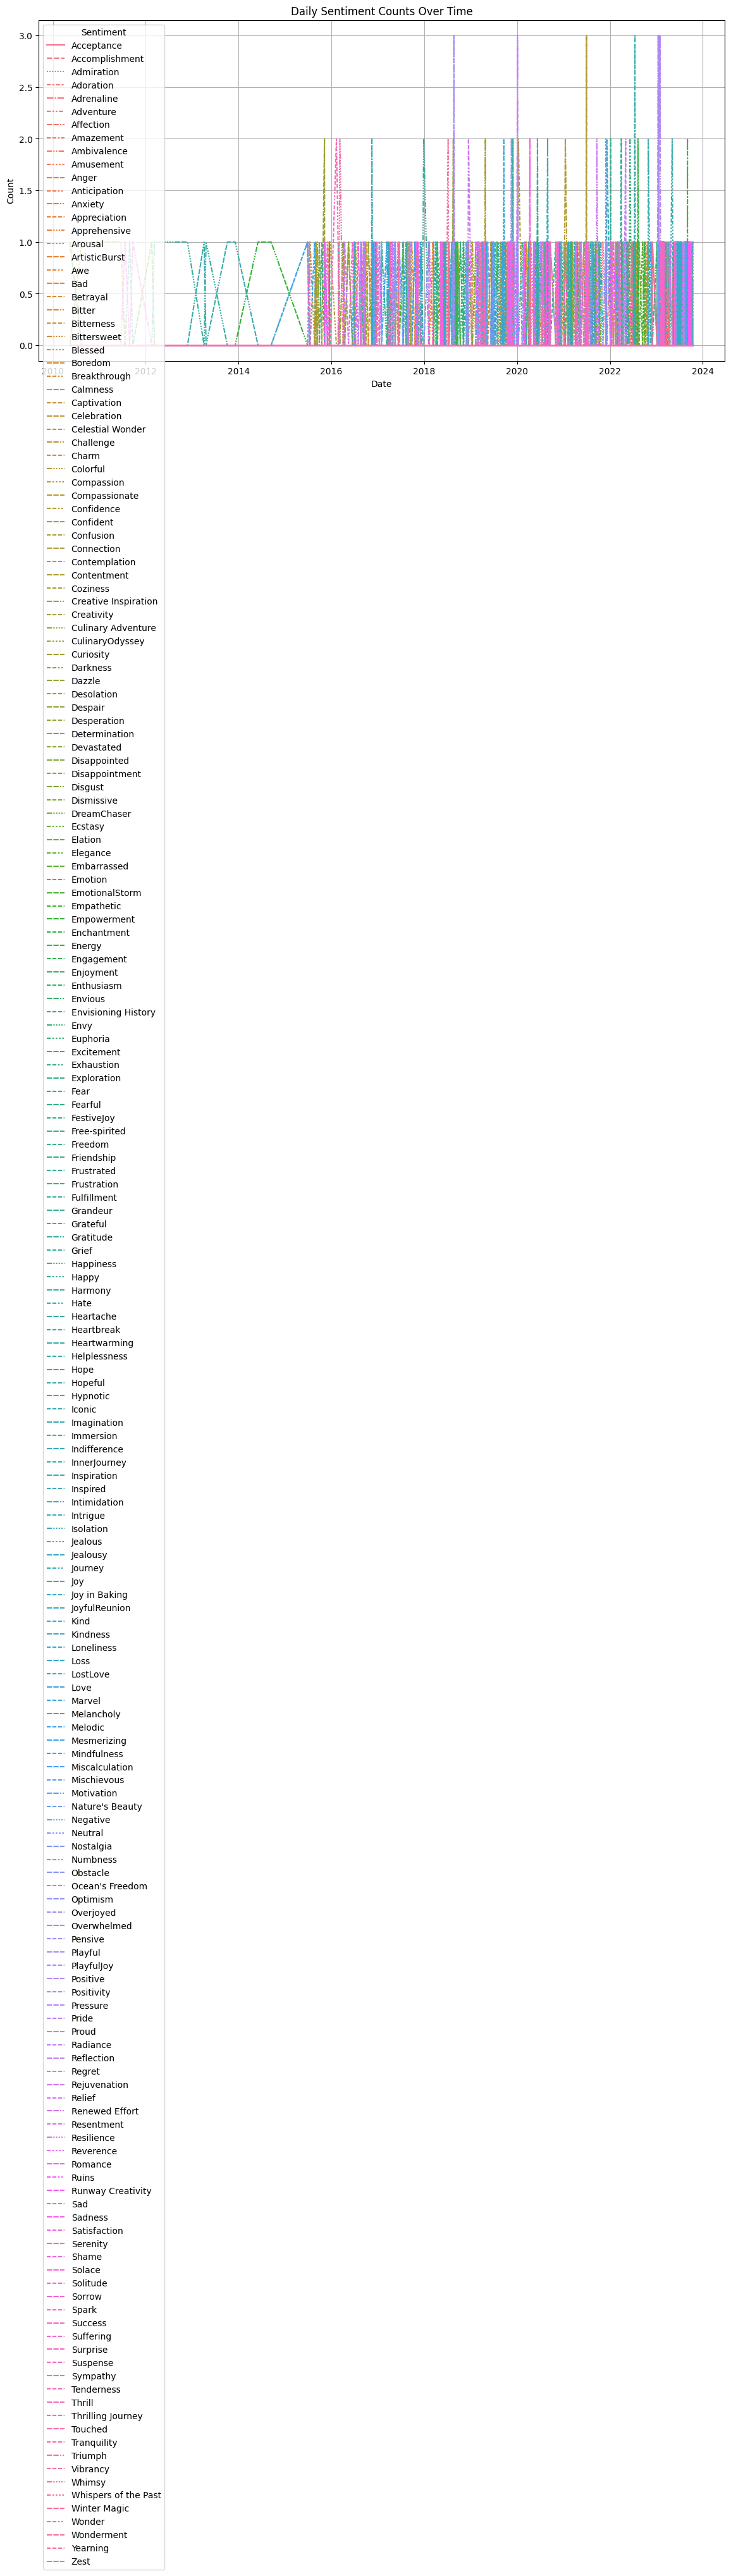

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.lineplot(data=daily_sentiment_counts)
plt.title('Daily Sentiment Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Count')
plt.legend(title='Sentiment')
plt.grid(True)
plt.tight_layout()
plt.show()

Next, decompose the time series for each sentiment into trend, seasonality, and residuals using `seasonal_decompose` from `statsmodels`. This will help us understand the underlying patterns more clearly. I used the 'Positive' sentiment as an example for decomposition.

Available sentiment columns for decomposition (after cleaning): ['Acceptance', 'Accomplishment', 'Admiration', 'Adoration', 'Adrenaline', 'Adventure', 'Affection', 'Amazement', 'Ambivalence', 'Amusement', 'Anger', 'Anticipation', 'Anxiety', 'Appreciation', 'Apprehensive', 'Arousal', 'ArtisticBurst', 'Awe', 'Bad', 'Betrayal', 'Bitter', 'Bitterness', 'Bittersweet', 'Blessed', 'Boredom', 'Breakthrough', 'Calmness', 'Captivation', 'Celebration', 'Celestial Wonder', 'Challenge', 'Charm', 'Colorful', 'Compassion', 'Compassionate', 'Confidence', 'Confident', 'Confusion', 'Connection', 'Contemplation', 'Contentment', 'Coziness', 'Creative Inspiration', 'Creativity', 'Culinary Adventure', 'CulinaryOdyssey', 'Curiosity', 'Darkness', 'Dazzle', 'Desolation', 'Despair', 'Desperation', 'Determination', 'Devastated', 'Disappointed', 'Disappointment', 'Disgust', 'Dismissive', 'DreamChaser', 'Ecstasy', 'Elation', 'Elegance', 'Embarrassed', 'Emotion', 'EmotionalStorm', 'Empathetic', 'Empowerment', 'Ench

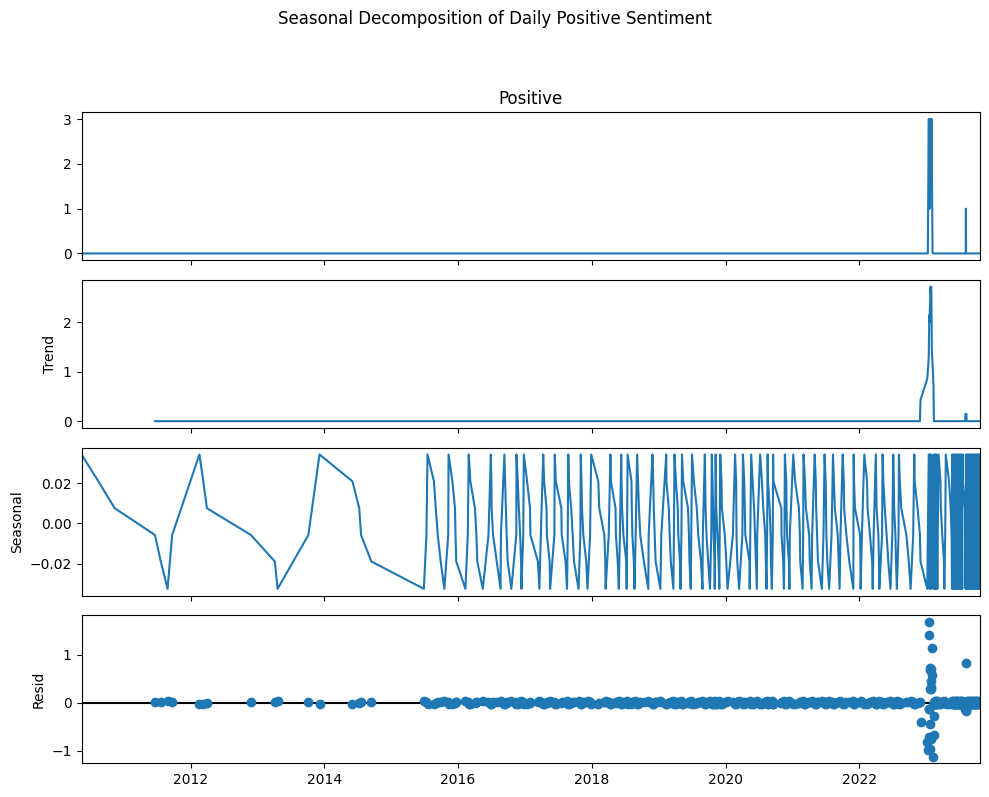

In [ ]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

# Ensure daily_sentiment_counts columns are stripped of any lingering whitespace
daily_sentiment_counts.columns = daily_sentiment_counts.columns.str.strip()

# Print available sentiment categories to identify the correct column name
print("Available sentiment columns for decomposition (after cleaning):", daily_sentiment_counts.columns.tolist())

num_days = daily_sentiment_counts.shape[0]
print(f"Number of unique days in the time series: {num_days}")

# Choose a sentiment column for decomposition, prioritizing common sentiments
sentiment_to_decompose = None
if 'Positive' in daily_sentiment_counts.columns:
    sentiment_to_decompose = 'Positive'
elif 'Neutral' in daily_sentiment_counts.columns:
    sentiment_to_decompose = 'Neutral'
elif 'Negative' in daily_sentiment_counts.columns:
    sentiment_to_decompose = 'Negative'
elif len(daily_sentiment_counts.columns) > 0:
    sentiment_to_decompose = daily_sentiment_counts.columns[0] # Fallback to the first available column

if sentiment_to_decompose is None:
    print("No suitable sentiment columns found for decomposition. Cannot proceed.")
elif num_days > 2 * 7: # At least two full periods for decomposition to make sense
    decomposition_selected_sentiment = seasonal_decompose(daily_sentiment_counts[sentiment_to_decompose], model='additive', period=7) # Assuming weekly seasonality

    fig = decomposition_selected_sentiment.plot()
    fig.set_size_inches(10, 8)
    fig.suptitle(f'Seasonal Decomposition of Daily {sentiment_to_decompose} Sentiment', y=1.02) # Adjust suptitle position
    plt.tight_layout(rect=[0, 0.03, 1, 0.98]) # Adjust layout to prevent suptitle overlap
    plt.show()
else:
    print(f"Not enough data points to perform seasonal decomposition for '{sentiment_to_decompose}' with a period of 7. Need at least 14 days ({num_days} available).")
    print("Consider a shorter period or check if data spans enough time.")

Implement moving average and exponential smoothing techniques.

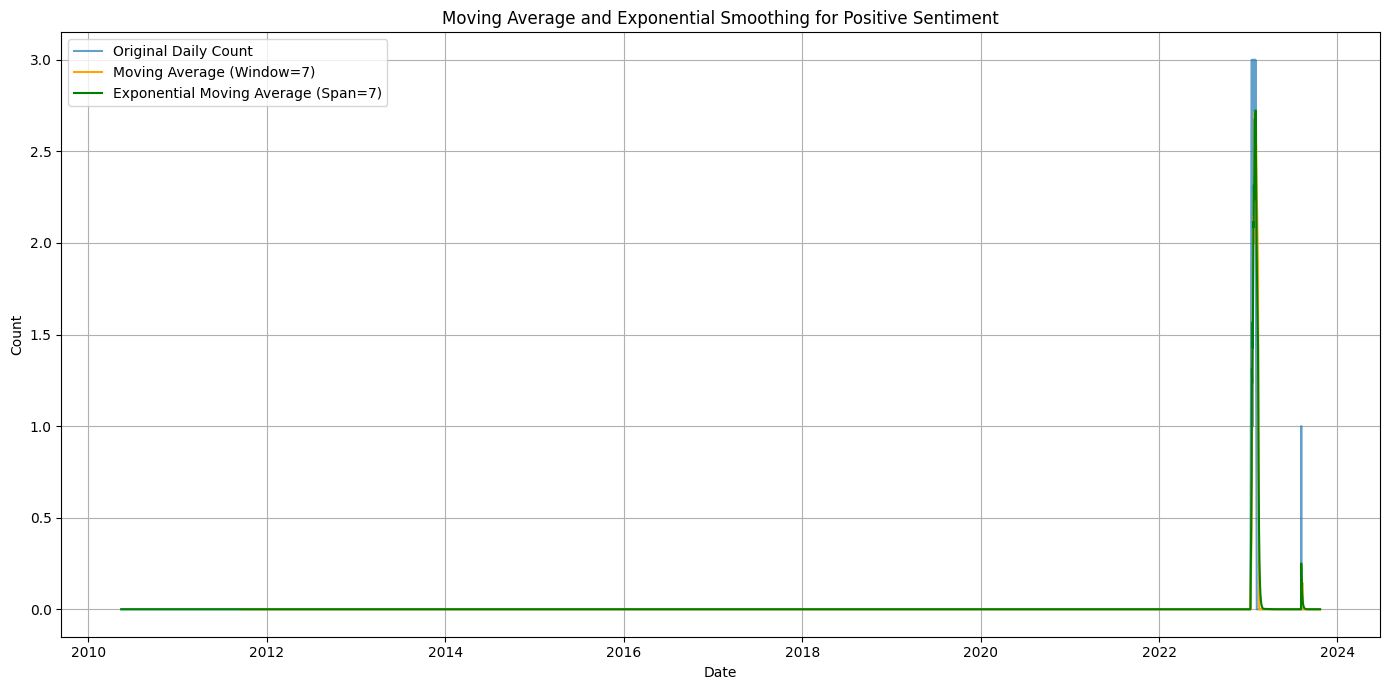

Sentiment,Positive,Positive_MA,Positive_EMA
Timestamp,,,
2010-05-15,0,NaN,0.0
2010-08-15,0,NaN,0.0
2010-11-12,0,NaN,0.0
2011-06-20,0,NaN,0.0
2011-07-22,0,NaN,0.0


In [ ]:
import matplotlib.pyplot as plt

# Ensure daily_sentiment_counts columns are stripped of any lingering whitespace
daily_sentiment_counts.columns = daily_sentiment_counts.columns.str.strip()

# Define the sentiment to apply smoothing techniques on, prioritizing common sentiments
sentiment_to_smooth = None
if 'Positive' in daily_sentiment_counts.columns:
    sentiment_to_smooth = 'Positive'
elif 'Neutral' in daily_sentiment_counts.columns:
    sentiment_to_smooth = 'Neutral'
elif 'Negative' in daily_sentiment_counts.columns:
    sentiment_to_smooth = 'Negative'
elif len(daily_sentiment_counts.columns) > 0:
    sentiment_to_smooth = daily_sentiment_counts.columns[0] # Fallback to the first available column

if sentiment_to_smooth is None:
    print("No suitable sentiment columns found for smoothing. Cannot proceed.")
else:
    # Calculate Moving Average (MA) - choosing a window of 7 days for weekly average
    window_size_ma = 7
    daily_sentiment_counts[f'{sentiment_to_smooth}_MA'] = daily_sentiment_counts[sentiment_to_smooth].rolling(window=window_size_ma).mean()

    # Calculate Exponential Moving Average (EMA) - choosing a span of 7 days
    span_ema = 7
    daily_sentiment_counts[f'{sentiment_to_smooth}_EMA'] = daily_sentiment_counts[sentiment_to_smooth].ewm(span=span_ema, adjust=False).mean()

    # Plotting the original, MA, and EMA series
    plt.figure(figsize=(14, 7))
    plt.plot(daily_sentiment_counts[sentiment_to_smooth], label='Original Daily Count', alpha=0.7)
    plt.plot(daily_sentiment_counts[f'{sentiment_to_smooth}_MA'], label=f'Moving Average (Window={window_size_ma})', color='orange')
    plt.plot(daily_sentiment_counts[f'{sentiment_to_smooth}_EMA'], label=f'Exponential Moving Average (Span={span_ema})', color='green')

    plt.title(f'Moving Average and Exponential Smoothing for {sentiment_to_smooth} Sentiment')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    display(daily_sentiment_counts[[sentiment_to_smooth, f'{sentiment_to_smooth}_MA', f'{sentiment_to_smooth}_EMA']].head())

### ARIMA/SARIMA Model Forecasting

To build an ARIMA or SARIMA mode, ensure the time series is stationary. This typically involves checking for trends and seasonality, and applying differencing if necessary. I'll continue using the 'Positive' sentiment for this analysis.

Performing Augmented Dickey-Fuller test for stationarity on 'Positive' sentiment:


,0
Test Statistic,-3.680729
p-value,0.004393
#Lags Used,19.000000
Number of Observations,513.000000
Critical Value (1%),-3.443162
Critical Value (5%),-2.867190
Critical Value (10%),-2.569780


The 'Positive' series is likely stationary (p-value <= 0.05).


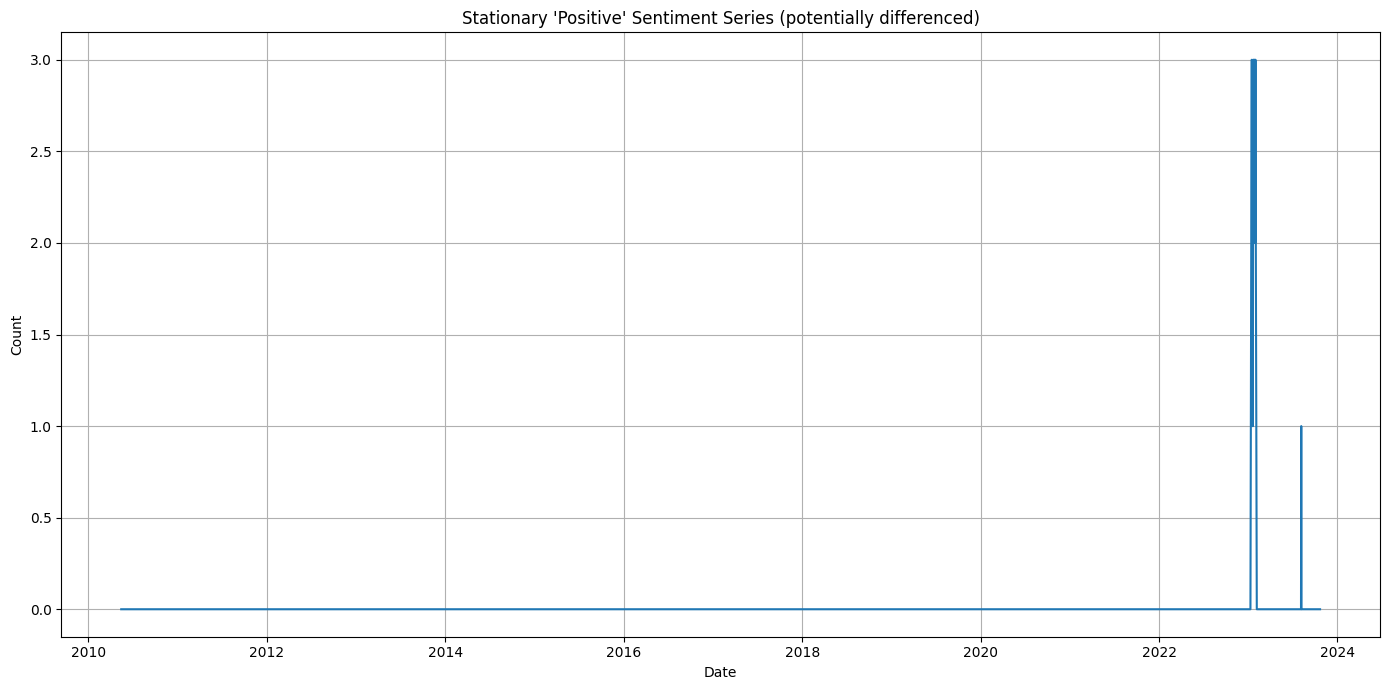

In [ ]:
from statsmodels.tsa.stattools import adfuller

# Select the sentiment series for modeling, prioritizing 'Positive'
sentiment_for_modeling = None
if 'Positive' in daily_sentiment_counts.columns:
    sentiment_for_modeling = 'Positive'
elif len(daily_sentiment_counts.columns) > 0:
    sentiment_for_modeling = daily_sentiment_counts.columns[0] # Fallback to the first available column

if sentiment_for_modeling is None:
    print("No suitable sentiment column found for ARIMA/SARIMA modeling. Cannot proceed.")
else:
    # Get the sentiment series
    ts = daily_sentiment_counts[sentiment_for_modeling]

    # Drop NaN values that might result from initial MA/EMA calculations if any
    ts = ts.dropna()

    print(f"Performing Augmented Dickey-Fuller test for stationarity on '{sentiment_for_modeling}' sentiment:")
    adf_test = adfuller(ts)
    adf_output = pd.Series(adf_test[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations'])
    for key, value in adf_test[4].items():
        adf_output[f'Critical Value ({key})'] = value
    display(adf_output)

    if adf_output['p-value'] <= 0.05:
        print(f"The '{sentiment_for_modeling}' series is likely stationary (p-value <= 0.05).")
        stationary_ts = ts
    else:
        print(f"The '{sentiment_for_modeling}' series is likely NOT stationary (p-value > 0.05). Differencing may be required.")
        # Try first-order differencing
        differenced_ts = ts.diff().dropna()
        print(f"\nPerforming ADF test on first-order differenced '{sentiment_for_modeling}' series:")
        adf_test_diff = adfuller(differenced_ts)
        adf_output_diff = pd.Series(adf_test_diff[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations'])
        for key, value in adf_test_diff[4].items():
            adf_output_diff[f'Critical Value ({key})'] = value
        display(adf_output_diff)
        if adf_output_diff['p-value'] <= 0.05:
            print(f"The first-order differenced '{sentiment_for_modeling}' series is likely stationary.")
            stationary_ts = differenced_ts
        else:
            print(f"Even after first-order differencing, the '{sentiment_for_modeling}' series is NOT stationary.")
            print("Further differencing or other transformations might be needed.")
            stationary_ts = ts # Revert to original if not stationary after first diff for now.

    # Plot the (potentially differenced) stationary series
    plt.figure(figsize=(14, 7))
    plt.plot(stationary_ts)
    plt.title(f"Stationary '{sentiment_for_modeling}' Sentiment Series (potentially differenced)")
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

### Determine ARIMA (p,q) Orders using ACF and PACF Plots
With a stationary series, we can use Autocorrelation Function (ACF) and Partial Autocorrelation Function (PACF) plots to help determine the orders for the AR (p) and MA (q) components of the ARIMA model. Since our series was already stationary, the 'd' (differencing order) will be 0.

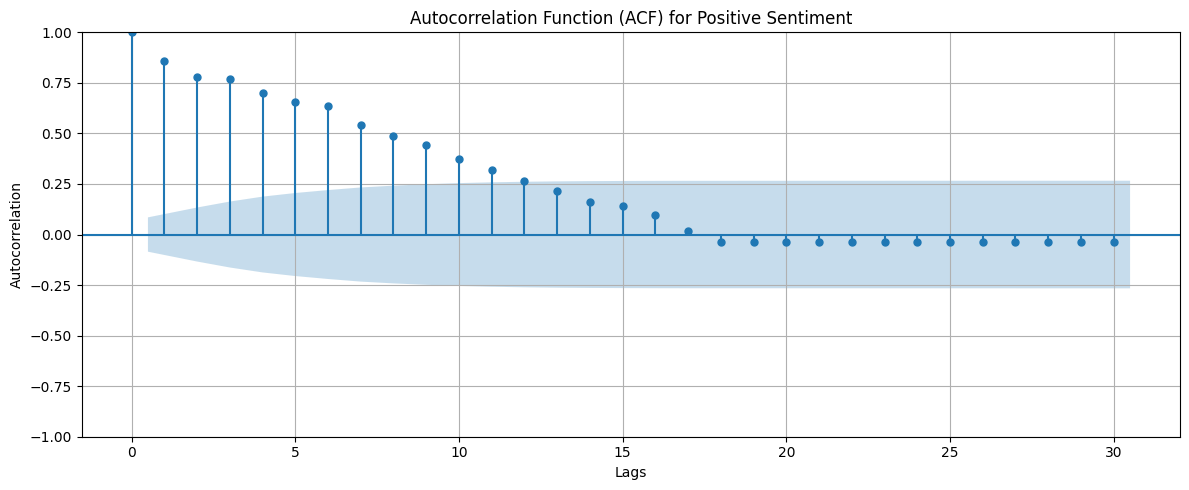

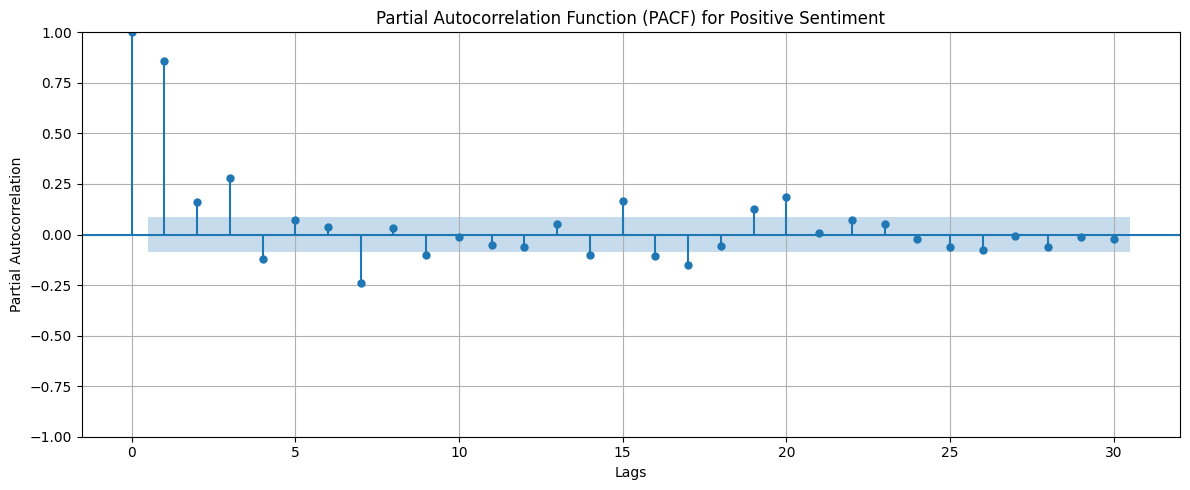

Based on the ACF and PACF plots, we can now choose suitable p and q values for the ARIMA model.
p: The lag value where the PACF plot crosses the upper confidence interval for the first time.
q: The lag value where the ACF plot crosses the upper confidence interval for the first time.


In [ ]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt

if sentiment_for_modeling is None:
    print("No sentiment selected for modeling. Cannot plot ACF/PACF.")
else:
    # Plot ACF
    plt.figure(figsize=(12, 5))
    plot_acf(stationary_ts, lags=30, ax=plt.gca())
    plt.title(f'Autocorrelation Function (ACF) for {sentiment_for_modeling} Sentiment')
    plt.xlabel('Lags')
    plt.ylabel('Autocorrelation')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    # Plot PACF
    plt.figure(figsize=(12, 5))
    plot_pacf(stationary_ts, lags=30, ax=plt.gca())
    plt.title(f'Partial Autocorrelation Function (PACF) for {sentiment_for_modeling} Sentiment')
    plt.xlabel('Lags')
    plt.ylabel('Partial Autocorrelation')
    plt.grid(True)
    plt.tight_layout()
    plt.show()

    print("Based on the ACF and PACF plots, we can now choose suitable p and q values for the ARIMA model.")
    print("p: The lag value where the PACF plot crosses the upper confidence interval for the first time.")
    print("q: The lag value where the ACF plot crosses the upper confidence interval for the first time.")

### Build and Fit ARIMA Model

Based on the visual inspection of the ACF and PACF plots, we will choose initial values for p and q. For now, let's assume `p=1` and `q=1` as a common starting point for demonstration purposes, and `d=0` since the series was found stationary.

Then, we will fit the ARIMA model and display its summary.

In [ ]:
from statsmodels.tsa.arima.model import ARIMA

if sentiment_for_modeling is None:
    print("No sentiment selected for modeling. Cannot build ARIMA model.")
else:
    # Define the ARIMA order (p, d, q)
    # Assuming p=1, d=0 (stationary), q=1 based on initial common practice, adjust after ACF/PACF review
    arima_order = (1, 0, 1)

    print(f"Building ARIMA model for '{sentiment_for_modeling}' with order {arima_order}")

    # Fit the ARIMA model
    # suppress warnings for convergence if they occur frequently during initial fitting attempts
    import warnings
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model = ARIMA(ts, order=arima_order)
        arima_results = model.fit()

    # Print model summary
    print(arima_results.summary())

    print("\nARIMA model built and fitted successfully. Review the summary for statistical significance and model diagnostics.")

Building ARIMA model for 'Positive' with order (1, 0, 1)
                               SARIMAX Results                                
Dep. Variable:               Positive   No. Observations:                  533
Model:                 ARIMA(1, 0, 1)   Log Likelihood                  25.183
Date:                Fri, 07 Aug 2026   AIC                            -42.365
Time:                        07:35:49   BIC                            -25.251
Sample:                             0   HQIC                           -35.668
                                - 533                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0805      0.299      0.269      0.788      -0.505       0.666
ar.L1          0.9312      0.012     80.730      0.000       0.909       0

### Evaluate ARIMA Model and Visualize Forecast

Evaluating the ARIMA model's performance by splitting the data into training and testing sets, making predictions, and then calculating metrics like RMSE. We will also visualize the forecast.

Training set size: 426
Testing set size: 107
Refitting ARIMA model with order (1, 0, 1) on training data...


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(



Root Mean Squared Error (RMSE): 0.124


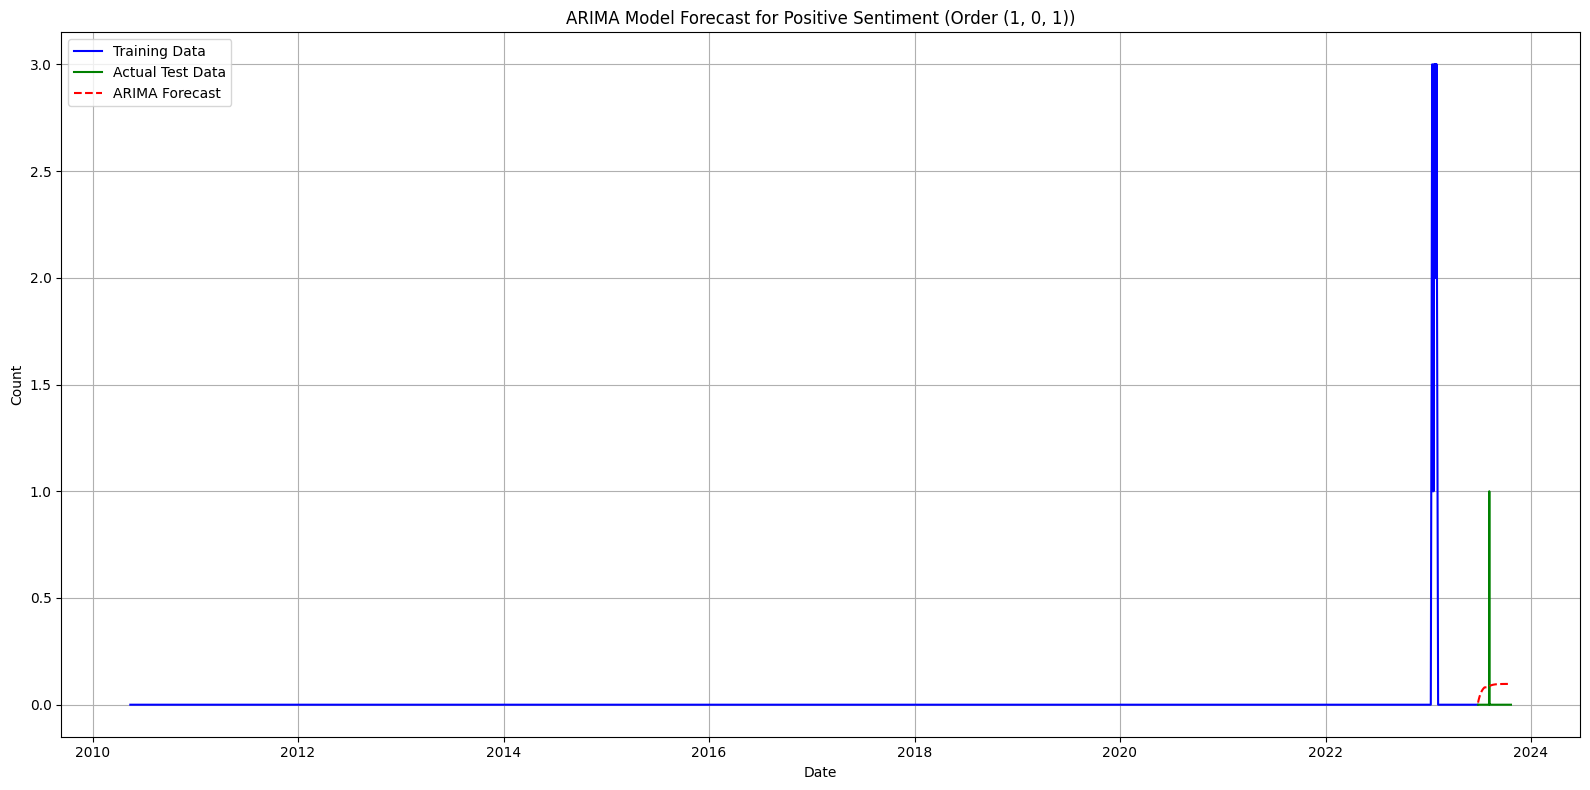

In [ ]:
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import numpy as np

if sentiment_for_modeling is None:
    print("No sentiment selected for modeling. Cannot evaluate ARIMA model.")
elif 'ts' not in locals():
    print("Time series 'ts' not found. Please ensure the previous steps for time series preparation are run.")
else:
    # Split data into training and testing sets
    train_size = int(len(ts) * 0.8) # 80% for training, 20% for testing
    train, test = ts[0:train_size], ts[train_size:]

    print(f"Training set size: {len(train)}")
    print(f"Testing set size: {len(test)}")

    # Refit the ARIMA model on the training data
    # Use the same order (p,d,q) determined previously
    print(f"Refitting ARIMA model with order {arima_order} on training data...")
    with warnings.catch_warnings():
        warnings.filterwarnings("ignore")
        model_train = ARIMA(train, order=arima_order)
        arima_results_train = model_train.fit()

    # Make predictions on the test set
    # The 'start' and 'end' parameters should correspond to the indices of the test set
    start_index = len(train)
    end_index = len(ts) - 1
    forecast = arima_results_train.predict(start=start_index, end=end_index)
    # Ensure the forecast has the same index as the test set for plotting
    forecast.index = test.index

    # Calculate RMSE
    rmse = np.sqrt(mean_squared_error(test, forecast))
    print(f"\nRoot Mean Squared Error (RMSE): {rmse:.3f}")

    # Plotting the forecast
    plt.figure(figsize=(16, 8))
    plt.plot(train.index, train, label='Training Data', color='blue')
    plt.plot(test.index, test, label='Actual Test Data', color='green')
    plt.plot(forecast.index, forecast, label='ARIMA Forecast', color='red', linestyle='--')
    plt.title(f'ARIMA Model Forecast for {sentiment_for_modeling} Sentiment (Order {arima_order})')
    plt.xlabel('Date')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()